# **Feature Extractor — interactive demo (users)**

## Libraries

In [1]:

import numpy as np, matplotlib.pyplot as plt, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

from core.config import LayoutConfig, GlobalConfig
from operators.image_io import ImageIO
from operators.feature_extractor import feature_extractor
from utils.nd_tools import show_plane  # helper for plane visualization
from utils.decorators import timer # helper for benchmarkin

## Configurations

In [2]:
# ImageIO configuration: NumPy input/output, HWC layout
layout_cfg = LayoutConfig(layout_name="HWC", layout_framework="numpy", layout_ensured_name="HWC")
global_cfg  = GlobalConfig(framework="numpy", output_format="numpy")
io = ImageIO(layout_cfg=layout_cfg, global_cfg=global_cfg)

print("Initialized ImageIO — framework:", global_cfg.framework, "| output:", global_cfg.output_format)

Initialized ImageIO — framework: numpy | output: numpy


## Image Directory

In [3]:
root = Path.cwd().parent.parent.parent / "03_EXAMPLES_DATA" / "Images"
images_path = sorted([str(p) for p in root.rglob("*.png")])
rand = random.randint(0, len(images_path) - 2)
print("Found images:", len(images_path))

Found images: 672


## Load random image and build runners

In [4]:
image = io.read_image(images_path[rand], framework="numpy")

def feat_runner(features, 
                diff_strategy, 
                processor_strategy, 
                conv_strategy, 
                edge_strategy="gradient",
                input_format="numpy", 
                output_format="numpy",):
    @timer(return_result=True, return_elapsed=True, name = diff_strategy + "_" + processor_strategy + "_" + conv_strategy)
    def _runner(img):
        return feature_extractor(img, 
                                features=features, 
                                edge_strategy=edge_strategy,
                                diff_strategy=diff_strategy, 
                                processor_strategy=processor_strategy, 
                                conv_strategy=conv_strategy,
                                framework=input_format, 
                                output_format=output_format,
                                layout_name='HWC',
                                layout_framework='numpy', 
                                combine_features=True
                                )
    return _runner

features  = ["gaussian_eigen",] # [["intensity", "mean", "std", "median", "kurtosis", "skewness"]]

vectorized_res, vectorized_time=feat_runner(features, "vectorized", "vectorized", "gaussian")(image)
classic_res, classic_time=feat_runner(features, "classic", "classic", "gaussian")(image)
torch_res, torch_time=feat_runner(features, "torch", "torch", "torch", input_format="torch")(image)
parallel_res, parallel_time=feat_runner(features, "parallel", "parallel", "gaussian")(image)
print("Computed: vectorized, classic, torch, parallel.")

Execution time for 'vectorized_vectorized_gaussian': 1.835 seconds
Execution time for 'classic_classic_gaussian': 2.095 seconds
Execution time for 'torch_torch_torch': 2.185 seconds
Execution time for 'parallel_parallel_gaussian': 1.836 seconds
Computed: vectorized, classic, torch, parallel.


## Visualisation

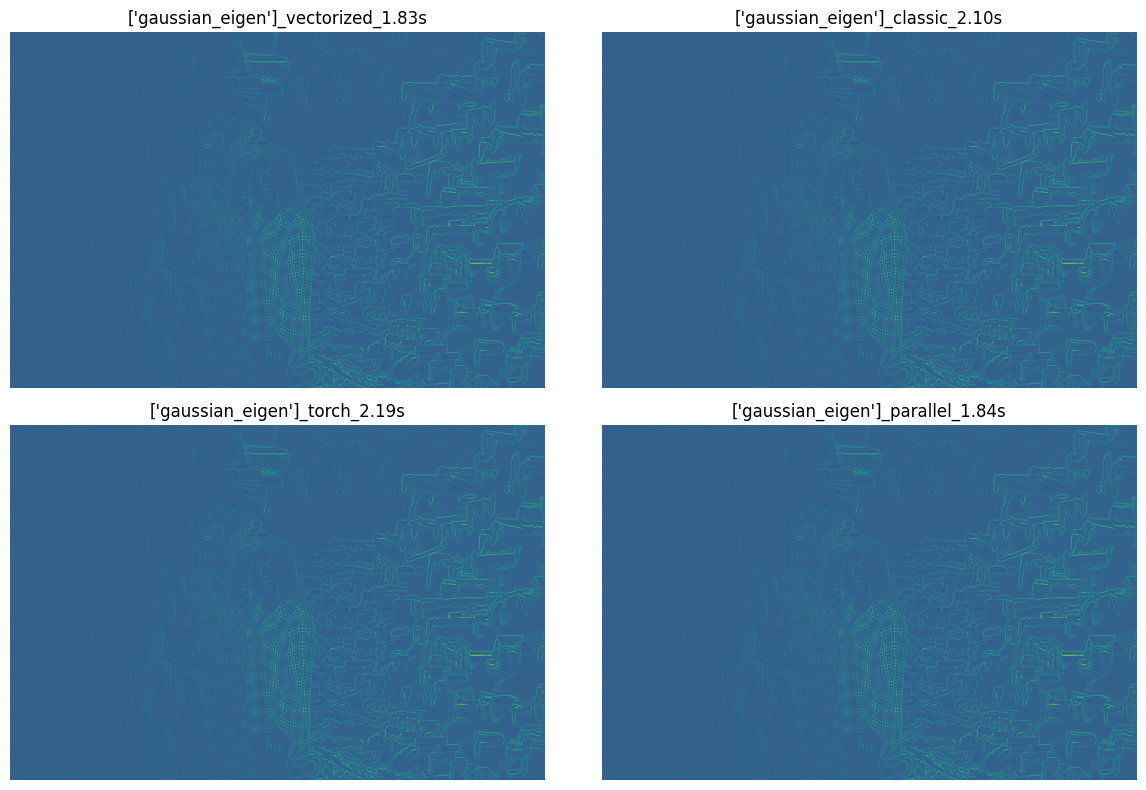

In [5]:
_, ((a,b), (c,d)) = plt.subplots(2, 2, figsize=(12, 8))

# Visualize features
c_idx, f_idx = 0, 0
cmap="auto" # "seismic", "jet", "Blues", "Reds", "inferno", "gray", "flag", "coolwarm", "plasma", "Greys_r"
colorbar = False

show_plane(a, vectorized_res, title=f"{features}_vectorized_{vectorized_time:.2f}s", cmap=cmap, channel_index=c_idx,
        feature_index=f_idx, norm = False, colorbar=colorbar, feature_type=features[0])
show_plane(b, classic_res, title=f"{features}_classic_{classic_time:.2f}s", cmap=cmap, channel_index=c_idx,
        feature_index=f_idx, norm = False, colorbar=colorbar, feature_type=features[0])
show_plane(c, torch_res, title=f"{features}_torch_{torch_time:.2f}s", cmap=cmap, channel_index=c_idx, 
        feature_index=f_idx, norm = False, colorbar=colorbar, feature_type=features[0])
show_plane(d, parallel_res, title=f"{features}_parallel_{parallel_time:.2f}s", cmap=cmap, channel_index=c_idx,
        feature_index=f_idx,norm = False, colorbar=colorbar,feature_type=features[0])

plt.tight_layout(); plt.show()